# Data Battle 2026 — Modélisation Complète
## Hawkes + XGBoost enrichi avec utils.py
### Pipeline : feature engineering complet → Hawkes → XGBoost hybride → métriques métier

---
**Architecture du notebook :**
1. Chargement & nettoyage
2. Feature engineering via `utils.py` (`compute_features`, `compute_surrounding_features`, `cluster_storms`)
3. Features Hawkes (état d'excitation, simulation τ)
4. Modèle hybride XGBoost (régression τ + classification `is_last`)
5. Évaluation complète (métriques stats + métriques métier)
6. Sauvegarde des modèles et résultats


## 1. Imports et configuration

In [1]:
import os, time, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import pearsonr

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    roc_auc_score, brier_score_loss, log_loss,
    average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
    print("✅ XGBoost disponible")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
    HAS_XGB = False
    print("⚠️  XGBoost absent — fallback sklearn GBM")

# utils.py doit être dans le même dossier que ce notebook
from utils import (
    compute_features,
    compute_surrounding_features,
    cluster_storms,
    evaluate_model,
    business_metric,
    plot_calibration_roc,
)

# ── Configuration ────────────────────────────────────────────────────────────
DATA_PATH    = "data_train_databattle2026/segment_alerts_all_airports_train.csv"
OUTPUT_DIR   = "hawkes_utils_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Hawkes
GAMMA               = 0.03
N_SIM               = 60
MAX_TIME_MIN        = 180
INTENSITY_THRESHOLD = 5e-5

# Split temporel (train ≤ 2022 | val 2023 | test 2024+)
TRAIN_YEAR_MAX = 2022
VAL_YEAR       = 2023

print(f"Output dir : {OUTPUT_DIR}")
print(f"Split : train ≤ {TRAIN_YEAR_MAX} | val = {VAL_YEAR} | test ≥ {VAL_YEAR+1}")


✅ XGBoost disponible
Output dir : hawkes_utils_outputs
Split : train ≤ 2022 | val = 2023 | test ≥ 2024


## 2. Chargement et nettoyage

In [2]:
print("=" * 60)
print("CHARGEMENT DES DONNÉES")
print("=" * 60)

df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"], low_memory=False)
df_raw["date"] = pd.to_datetime(df_raw["date"], utc=True, errors="coerce")

# Normalisation booléens
for col in ["icloud", "is_last_lightning_cloud_ground"]:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].map({
            "VRAI": True, "FAUX": False,
            "True": True, "False": False,
            True: True, False: False,
            1: True, 0: False
        })

# Exclusion Pise 2016 (enregistrement IC différent)
mask_pise = (df_raw["airport"] == "Pise") & (df_raw["date"].dt.year == 2016)
df_raw = df_raw[~mask_pise].copy()
print(f"Pise 2016 exclus : {mask_pise.sum()} lignes")

df_raw = df_raw[df_raw["date"].notna()].copy()
df_raw = df_raw.sort_values(["airport", "airport_alert_id", "date"]).reset_index(drop=True)

print(f"\nDataset brut : {df_raw.shape}")
print(f"Période      : {df_raw['date'].min()} → {df_raw['date'].max()}")
print(f"Aéroports    : {sorted(df_raw['airport'].unique())}")
print(f"Alertes tot. : {df_raw['airport_alert_id'].nunique()}")
print(f"Éclairs CG   : {(~df_raw['icloud'].fillna(False)).sum()}")
print(f"Éclairs IC   : {df_raw['icloud'].fillna(False).sum()}")

df_raw.head(3)


CHARGEMENT DES DONNÉES
Pise 2016 exclus : 24421 lignes

Dataset brut : (482650, 13)
Période      : 2016-01-02 01:10:41+00:00 → 2022-12-21 11:20:11+00:00
Aéroports    : ['Ajaccio', 'Bastia', 'Biarritz', 'Nantes', 'Pise']
Alertes tot. : 769
Éclairs CG   : 123975
Éclairs IC   : 358675


,lightning_id,lightning_airport_id,date,lon,lat,amplitude,maxis,icloud,dist,azimuth,airport,airport_alert_id,is_last_lightning_cloud_ground
0,4,4,2016-01-02 21:22:53+00:00,8.8517,42.0517,-7.51,0.2,False,14.794117,20.854458,Ajaccio,1.0,False
1,5,5,2016-01-02 21:24:46+00:00,8.8728,42.0494,-6.01,0.2,False,15.124224,29.058471,Ajaccio,1.0,False
2,6,6,2016-01-02 21:25:59+00:00,8.8495,42.0595,-23.96,2.6,False,15.583922,18.926800,Ajaccio,1.0,False


## 3. Feature engineering — `utils.py`
### 3.1 CG intra-alerte (`compute_features`)


In [3]:
print("=" * 60)
print("COMPUTE_FEATURES (CG intra-alerte)")
print("=" * 60)

# compute_features ne travaille que sur les CG avec une alerte
df_cg = df_raw[
    (~df_raw["icloud"].fillna(False)) &
    (df_raw["airport_alert_id"].notna())
].copy()

t0 = time.time()
df_cg = compute_features(df_cg)
print(f"compute_features : {time.time()-t0:.1f}s — {df_cg.shape[1]} colonnes")
print(f"Nouvelles features : {[c for c in df_cg.columns if c not in df_raw.columns][:10]} ...")


COMPUTE_FEATURES (CG intra-alerte)
compute_features : 19.9s — 60 colonnes
Nouvelles features : ['inter_time_s', 'inter_time_log', 'median_inter', 'mean_inter', 'std_inter', 'max_inter', 'ratio_median', 'ratio_mean', 'z_score_inter', 'ratio_max'] ...


### 3.2 Features IC et CG entourant (`compute_surrounding_features`)

In [4]:
print("=" * 60)
print("COMPUTE_SURROUNDING_FEATURES")
print("=" * 60)

t0 = time.time()
df_cg = compute_surrounding_features(df_cg, df_raw)
print(f"compute_surrounding_features : {time.time()-t0:.1f}s")
print(f"Features ajoutées : {[c for c in df_cg.columns if 'ic' in c or 'surr' in c or 'ratio_surr' in c]}")


COMPUTE_SURROUNDING_FEATURES
compute_surrounding_features : 0.4s
Features ajoutées : ['icloud', 'n_ic_5m', 'n_ic_15m', 'n_ic_30m', 'n_cg_surr_5m', 'n_cg_surr_15m', 'n_cg_surr_30m', 'ratio_surr_5m', 'ratio_surr_15m', 'ratio_surr_30m']


### 3.3 Clustering des types d'orages (`cluster_storms`)

In [5]:
print("=" * 60)
print("CLUSTER_STORMS (K-Means 4 clusters)")
print("=" * 60)

t0 = time.time()
df_cg = cluster_storms(df_cg, n_clusters=4, seed=RANDOM_STATE)
print(f"cluster_storms : {time.time()-t0:.1f}s")
print(f"Distribution des clusters :\n{df_cg['storm_cluster'].value_counts().sort_index()}")


CLUSTER_STORMS (K-Means 4 clusters)
=== Clusters d'orages (train ≤ 2020) ===
  Cluster 0 (n=773) : durée=6min, n_CG=2, inter_med=62s, dist=17.2km, heure=12h
  Cluster 1 (n=717) : durée=55min, n_CG=25, inter_med=183s, dist=13.5km, heure=11h
  Cluster 2 (n= 43) : durée=226min, n_CG=415, inter_med=23s, dist=13.2km, heure=10h
  Cluster 3 (n=269) : durée=4min, n_CG=1, inter_med=36s, dist=8.8km, heure=13h
cluster_storms : 3.8s
Distribution des clusters :
storm_cluster
0     3061
1    26146
2    24455
3      808
Name: count, dtype: int64


## 4. Features Hawkes et cibles

In [6]:
print("=" * 60)
print("CONSTRUCTION DES FEATURES TEMPORELLES HAWKES")
print("=" * 60)

# Temps relatif dans l'alerte
first_time = df_cg.groupby(["airport", "airport_alert_id"])["date"].transform("min")
last_time  = df_cg.groupby(["airport", "airport_alert_id"])["date"].transform("max")

df_cg["t_min"]        = (df_cg["date"] - first_time).dt.total_seconds() / 60
df_cg["tau_true_min"] = (last_time - df_cg["date"]).dt.total_seconds() / 60
df_cg["log_tau_true"] = np.log1p(df_cg["tau_true_min"])

# Index et progression
df_cg["event_idx"]    = df_cg.groupby(["airport", "airport_alert_id"]).cumcount()
df_cg["n_events"]     = df_cg.groupby(["airport", "airport_alert_id"])["event_idx"].transform("max") + 1
df_cg["progress_ratio"] = np.where(
    df_cg["n_events"] > 1,
    df_cg["event_idx"] / (df_cg["n_events"] - 1),
    1.0
)

# Inter-temps rolling (Hawkes)
df_cg["dt_prev"] = df_cg.groupby(["airport", "airport_alert_id"])["t_min"].diff().fillna(0)
df_cg["rolling_mean_dt"] = df_cg.groupby(["airport", "airport_alert_id"])["dt_prev"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
df_cg["rolling_std_dt"] = df_cg.groupby(["airport", "airport_alert_id"])["dt_prev"].transform(
    lambda x: x.rolling(5, min_periods=1).std()
).fillna(0)

# icloud_recent (pour la simulation Hawkes)
df_cg["icloud_int"]    = 0  # CG only → toujours 0 dans df_cg
df_cg["icloud_ratio"]  = 0.0
df_cg["icloud_recent"] = 0.0

# Interaction
df_cg["dist_amp_interaction"] = df_cg["dist"].fillna(0) * df_cg["amp_abs"].fillna(0)

# Encodage cyclique (redondant avec utils mais cohérent)
df_cg["hour_sin"]  = np.sin(2 * np.pi * df_cg["hour"]  / 24)
df_cg["hour_cos"]  = np.cos(2 * np.pi * df_cg["hour"]  / 24)
df_cg["month_sin"] = np.sin(2 * np.pi * df_cg["month"] / 12)
df_cg["month_cos"] = np.cos(2 * np.pi * df_cg["month"] / 12)
df_cg["dayofyear"] = df_cg["date"].dt.dayofyear

# Cible classification : is_last_lightning_cloud_ground
if "is_last_lightning_cloud_ground" in df_cg.columns:
    df_cg["is_last"] = df_cg["is_last_lightning_cloud_ground"].fillna(False).astype(int)
else:
    # Reconstruction depuis tau_true_min
    df_cg["is_last"] = (df_cg["tau_true_min"] == 0).astype(int)

print(f"Taux de 'derniers éclairs' : {df_cg['is_last'].mean():.3%}")
print(f"Shape final df_cg : {df_cg.shape}")


CONSTRUCTION DES FEATURES TEMPORELLES HAWKES
Taux de 'derniers éclairs' : 4.406%
Shape final df_cg : (54470, 89)


## 5. Split temporel (train / val / test par année)

In [7]:
print("=" * 60)
print("SPLIT TEMPOREL PAR ANNÉE")
print("=" * 60)

df_cg["year"] = df_cg["date"].dt.year

df_cg["split"] = "train"
df_cg.loc[df_cg["year"] == VAL_YEAR,       "split"] = "val"
df_cg.loc[df_cg["year"] >  VAL_YEAR,       "split"] = "test"

for s in ["train", "val", "test"]:
    sub = df_cg[df_cg["split"] == s]
    n_alertes = sub["airport_alert_id"].nunique()
    print(f"  {s:6s} : {len(sub):6d} éclairs | {n_alertes:4d} alertes "
          f"| années {sorted(sub['year'].unique())}")


SPLIT TEMPOREL PAR ANNÉE
  train  :  54470 éclairs |  769 alertes | années [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
  val    :      0 éclairs |    0 alertes | années []
  test   :      0 éclairs |    0 alertes | années []


## 6. Ajustement des paramètres Hawkes (sur train uniquement)

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Fonctions Hawkes (identiques au notebook initial)
# ──────────────────────────────────────────────────────────────────────────────

def hawkes_loglik_sequence(times, ic, mu, alpha, beta, delta):
    n = len(times)
    if n < 2:
        return 0.0
    g_all = np.zeros(n)
    g_ic  = np.zeros(n)
    for i in range(1, n):
        dt     = times[i] - times[i - 1]
        decay  = np.exp(-beta * dt)
        g_all[i] = decay * (g_all[i-1] + 1.0)
        g_ic[i]  = decay * (g_ic[i-1]  + float(ic[i-1]))
    lambdas = mu + alpha * g_all + delta * g_ic
    if np.any(lambdas <= 1e-12):
        return 1e12
    ll = np.sum(np.log(lambdas))
    T  = times[-1]
    comp  = mu * T
    comp += (alpha / beta) * np.sum(1.0 - np.exp(-beta * (T - times)))
    comp += (delta / beta) * np.sum(ic   * (1.0 - np.exp(-beta * (T - times))))
    penalty = 1e6 * (alpha - beta + 1e-6)**2 if alpha >= beta else 0.0
    return -(ll - comp) + penalty

def hawkes_total_negloglik(params, sequences):
    mu, alpha, beta, delta = params
    if mu <= 1e-8 or alpha < 0 or beta <= 0 or delta < 0:
        return 1e18
    total = sum(hawkes_loglik_sequence(t, ic, mu, alpha, beta, delta)
                for t, ic in sequences)
    return total if np.isfinite(total) else 1e18

def optimize_hawkes(sequences):
    inits = [
        (0.005,0.05,0.10,0.01),(0.010,0.08,0.15,0.02),
        (0.010,0.10,0.20,0.03),(0.008,0.12,0.25,0.05),
        (0.003,0.06,0.12,0.01),(0.020,0.15,0.30,0.05),
    ]
    best_ll, best_p = np.inf, None
    for init in inits:
        try:
            res = minimize(hawkes_total_negloglik, x0=init, args=(sequences,),
                           method="L-BFGS-B",
                           bounds=[(1e-6,0.10),(1e-6,1.0),(1e-6,1.5),(0.0,1.0)],
                           options={"maxiter": 400, "ftol": 1e-8})
            if res.success and res.fun < best_ll:
                best_ll, best_p = res.fun, res.x
        except Exception:
            pass
    if best_p is None:
        best_p = np.array([0.01, 0.15, 0.30, 0.02])
    mu, alpha, beta, delta = best_p
    if alpha >= beta:
        alpha = 0.95 * beta
    return float(mu), float(alpha), float(beta), float(delta)

def compute_post_event_state(times, ic, beta):
    n = len(times)
    z_all, z_ic = np.zeros(n), np.zeros(n)
    if n == 0:
        return z_all, z_ic
    z_all[0] = 1.0
    z_ic[0]  = float(ic[0])
    for i in range(1, n):
        dt = times[i] - times[i-1]
        d  = np.exp(-beta * dt)
        z_all[i] = d * z_all[i-1] + 1.0
        z_ic[i]  = d * z_ic[i-1]  + float(ic[i])
    return z_all, z_ic

def simulate_hawkes(mu, alpha, beta, delta, gamma, z_all0, z_ic0,
                    p_ic=0.0, max_t=180, threshold=5e-5, n_sim=60, seed=42):
    rng = np.random.default_rng(seed)
    samples = np.zeros(n_sim)
    for s in range(n_sim):
        t, z_all, z_ic, last = 0.0, float(z_all0), float(z_ic0), 0.0
        has = False
        while True:
            lam = (mu + alpha*z_all + delta*z_ic) * np.exp(-gamma*t)
            if lam < threshold: break
            w = rng.exponential(1.0 / max(lam, 1e-12))
            tc = t + w
            if tc > max_t: break
            d  = np.exp(-beta * w)
            za = z_all * d; zi = z_ic * d
            lc = (mu + alpha*za + delta*zi) * np.exp(-gamma*tc)
            if rng.uniform() <= min(1.0, lc / max(lam, 1e-12)):
                t, z_all, z_ic = tc, za+1.0, zi+float(rng.uniform()<p_ic)
                last = t; has = True
            else:
                t, z_all, z_ic = tc, za, zi
        samples[s] = last if has else 0.0
    return {
        "tau_mean":          float(np.mean(samples)),
        "tau_median":        float(np.median(samples)),
        "tau_q05":           float(np.percentile(samples, 5)),
        "tau_q95":           float(np.percentile(samples, 95)),
        "tau_std":           float(np.std(samples)),
        "p_finished_30min":  float(np.mean(samples < 30.0)),
        "p_finished_60min":  float(np.mean(samples < 60.0)),
    }

# ── Ajustement sur train ──────────────────────────────────────────────────────
print("Préparation des séquences d'entraînement...")
train_seq = []
for (ap, aid), g in df_cg[df_cg["split"]=="train"].groupby(
        ["airport","airport_alert_id"], sort=False):
    g = g.sort_values("t_min")
    if len(g) >= 3:
        train_seq.append((g["t_min"].values, g["icloud_int"].values))

print(f"Séquences train (≥3 éclairs) : {len(train_seq)}")

t0 = time.time()
mu_opt, alpha_opt, beta_opt, delta_opt = optimize_hawkes(train_seq)
print(f"\n✅ Paramètres Hawkes ({time.time()-t0:.1f}s) :")
print(f"   μ={mu_opt:.6f}  α={alpha_opt:.6f}  β={beta_opt:.6f}  δ={delta_opt:.6f}")
print(f"   α/β = {alpha_opt/beta_opt:.4f}  (stationnaire si <1)")


Préparation des séquences d'entraînement...
Séquences train (≥3 éclairs) : 1259

✅ Paramètres Hawkes (58.4s) :
   μ=0.100000  α=0.222866  β=0.251215  δ=0.050000
   α/β = 0.8872  (stationnaire si <1)


## 7. Calcul de l'état d'excitation post-événement

In [9]:
print("Calcul des états d'excitation...")
df_cg["z_all_post"] = 0.0
df_cg["z_ic_post"]  = 0.0
df_cg["lambda_now"] = 0.0

for (ap, aid), g in df_cg.groupby(["airport","airport_alert_id"], sort=False):
    g  = g.sort_values("t_min")
    za, zi = compute_post_event_state(
        g["t_min"].values, g["icloud_int"].values, beta_opt)
    idx = g.index
    df_cg.loc[idx, "z_all_post"] = za
    df_cg.loc[idx, "z_ic_post"]  = zi
    df_cg.loc[idx, "lambda_now"] = mu_opt + alpha_opt*za + delta_opt*zi

print(f"✅ z_all moyen : {df_cg['z_all_post'].mean():.2f}")
print(f"   λ moyen     : {df_cg['lambda_now'].mean():.4f} /min")


Calcul des états d'excitation...
✅ z_all moyen : 13.41
   λ moyen     : 3.0892 /min


## 8. Simulation Hawkes (prédiction τ)

In [10]:
print(f"Simulation Hawkes ({N_SIM} tirages / éclair)...")
print(f"Dataset : {len(df_cg)} éclairs — peut prendre quelques minutes")

predictions = []
for i, row in enumerate(df_cg.itertuples(index=False), 1):
    pred = simulate_hawkes(
        mu_opt, alpha_opt, beta_opt, delta_opt, GAMMA,
        row.z_all_post, row.z_ic_post, p_ic=0.0,
        max_t=MAX_TIME_MIN, threshold=INTENSITY_THRESHOLD,
        n_sim=N_SIM, seed=RANDOM_STATE + i
    )
    predictions.append(pred)
    if i % 10000 == 0:
        print(f"  {i}/{len(df_cg)}")

pred_df = pd.DataFrame(predictions).add_prefix("tau_pred_")
df_cg = pd.concat([df_cg.reset_index(drop=True),
                   pred_df.reset_index(drop=True)], axis=1)

print(f"\n✅ Prédictions Hawkes calculées")
print(df_cg[["tau_true_min","tau_pred_tau_mean","tau_pred_p_finished_30min"]].describe().round(2))


Simulation Hawkes (60 tirages / éclair)...
Dataset : 54470 éclairs — peut prendre quelques minutes
  10000/54470
  20000/54470
  30000/54470
  40000/54470
  50000/54470

✅ Prédictions Hawkes calculées
       tau_true_min  tau_pred_tau_mean  tau_pred_p_finished_30min
count      54470.00           54470.00                   54470.00
mean          82.37              60.20                       0.20
std           82.13               4.66                       0.06
min            0.00              42.68                       0.00
25%           26.58              57.04                       0.17
50%           57.05              60.15                       0.20
75%          113.40              63.30                       0.25
max          578.72              80.52                       0.47


## 9. Features finales pour XGBoost

In [11]:
# ── Features utils.py ────────────────────────────────────────────────────────
FEATURES_UTILS = [
    # Inter-temps
    "inter_time_s", "inter_time_log",
    "median_inter", "mean_inter", "std_inter", "max_inter",
    "ratio_median", "ratio_mean", "z_score_inter", "ratio_max",
    "inter_trend", "prev_inter", "inter_accel",
    # Contexte alerte
    "n_cg_cumul", "alert_dur_min",
    # Amplitude
    "amp_abs", "is_positive",
    "pct_pos_cumul", "pct_pos_last5", "pct_pos_last10",
    "amp_trend", "amp_abs_trend",
    # Fenêtres
    "n_cg_5m", "n_cg_10m", "n_cg_15m",
    # Distance / azimuth
    "mean_dist_5", "mean_dist_10", "dist_vs_mean5", "dist_trend",
    "az_dispersion", "dist_is_increasing",
    # Centroïde
    "centroid_x_5", "centroid_y_5", "centroid_x_10", "centroid_y_10",
    "centroid_dist_ap", "centroid_dx", "centroid_dy",
    "centroid_speed", "centroid_dist_trend", "centroid_approach",
    # Entourant IC/CG
    "n_ic_5m", "n_ic_15m", "n_ic_30m",
    "n_cg_surr_5m", "n_cg_surr_15m", "n_cg_surr_30m",
    "ratio_surr_5m", "ratio_surr_15m", "ratio_surr_30m",
    # Cluster orage
    "storm_cluster",
    # Temporel
    "month", "hour", "season", "airport_enc",
]

# ── Features Hawkes ───────────────────────────────────────────────────────────
FEATURES_HAWKES = [
    "tau_pred_tau_mean", "tau_pred_tau_median",
    "tau_pred_tau_q05", "tau_pred_tau_q95", "tau_pred_tau_std",
    "tau_pred_p_finished_30min", "tau_pred_p_finished_60min",
    "z_all_post", "z_ic_post", "lambda_now",
]

# ── Features dynamiques (Hawkes notebook initial) ────────────────────────────
FEATURES_DYN = [
    "event_idx", "n_events", "progress_ratio",
    "dt_prev", "rolling_mean_dt", "rolling_std_dt",
    "dist", "azimuth", "dist_amp_interaction",
    "x_pos", "y_pos",
    "hour_sin", "hour_cos", "month_sin", "month_cos", "dayofyear",
]

# Fusion — garder uniquement les colonnes existantes
ALL_FEATURES = list(dict.fromkeys(FEATURES_UTILS + FEATURES_HAWKES + FEATURES_DYN))
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_cg.columns]

print(f"Features utils.py disponibles : {len([f for f in FEATURES_UTILS if f in df_cg.columns])}/{len(FEATURES_UTILS)}")
print(f"Features Hawkes               : {len([f for f in FEATURES_HAWKES if f in df_cg.columns])}/{len(FEATURES_HAWKES)}")
print(f"Features dynamiques           : {len([f for f in FEATURES_DYN if f in df_cg.columns])}/{len(FEATURES_DYN)}")
print(f"Total features XGBoost        : {len(ALL_FEATURES)}")

# Features manquantes (à vérifier)
missing = [f for f in FEATURES_UTILS + FEATURES_HAWKES if f not in df_cg.columns]
if missing:
    print(f"\n⚠️  Features manquantes : {missing}")


Features utils.py disponibles : 55/55
Features Hawkes               : 10/10
Features dynamiques           : 16/16
Total features XGBoost        : 81


## 10. Entraînement XGBoost — Régression τ + Classification is_last

In [14]:
print("=" * 60)
print("ENTRAÎNEMENT XGBOOST")
print("=" * 60)

# ── Split masks avec diagnostic et fallback ───────────────────────────────────
df_cg["split"] = "train"
df_cg.loc[df_cg["year"] == VAL_YEAR, "split"] = "val"
df_cg.loc[df_cg["year"] >  VAL_YEAR, "split"] = "test"

for s in ["train", "val", "test"]:
    sub = df_cg[df_cg["split"] == s]
    print(f"  {s:6s} : {len(sub):6d} éclairs | années {sorted(sub['year'].unique())}")

# Si test vide → 2 dernières années du train deviennent test
if (df_cg["split"] == "test").sum() == 0:
    print("  ⚠️  Test vide — réaffectation des 2 dernières années")
    last_years = sorted(df_cg["year"].unique())[-2:]
    df_cg.loc[df_cg["year"].isin(last_years), "split"] = "test"
    remaining_years = sorted(df_cg[df_cg["split"] == "train"]["year"].unique())
    if len(remaining_years) >= 1:
        df_cg.loc[df_cg["year"] == remaining_years[-1], "split"] = "val"
    for s in ["train", "val", "test"]:
        sub = df_cg[df_cg["split"] == s]
        print(f"  {s:6s} (corrigé) : {len(sub):6d} éclairs | années {sorted(sub['year'].unique())}")

train_mask = df_cg["split"] == "train"
val_mask   = df_cg["split"] == "val"
test_mask  = df_cg["split"] == "test"

X_train = df_cg.loc[train_mask, ALL_FEATURES].fillna(0)
X_val   = df_cg.loc[val_mask,   ALL_FEATURES].fillna(0)
X_test  = df_cg.loc[test_mask,  ALL_FEATURES].fillna(0)

y_train_log  = df_cg.loc[train_mask, "log_tau_true"].values
y_train_tau  = df_cg.loc[train_mask, "tau_true_min"].values
y_val_tau    = df_cg.loc[val_mask,   "tau_true_min"].values
y_test_tau   = df_cg.loc[test_mask,  "tau_true_min"].values

y_train_last = df_cg.loc[train_mask, "is_last"].values
y_val_last   = df_cg.loc[val_mask,   "is_last"].values
y_test_last  = df_cg.loc[test_mask,  "is_last"].values

print(f"\nTrain : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")
print(f"Taux is_last — train:{y_train_last.mean():.3%}  val:{y_val_last.mean():.3%}  test:{y_test_last.mean():.3%}")

# ── 10.1 Régression τ ─────────────────────────────────────────────────────────
print("\n[1/2] Régression log(τ)...")

if len(X_val) > 0:
    eval_set_reg = [(X_val, np.log1p(y_val_tau))]
else:
    eval_set_reg = [(X_train, y_train_log)]

if HAS_XGB:
    model_reg = XGBRegressor(
        n_estimators=500, max_depth=8, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        early_stopping_rounds=30,
    )
    model_reg.fit(X_train, y_train_log,
                  eval_set=eval_set_reg,
                  verbose=False)
else:
    from sklearn.ensemble import GradientBoostingRegressor
    model_reg = GradientBoostingRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE)
    model_reg.fit(X_train, y_train_log)

print("  ✅ Régression entraînée")

# ── 10.2 Classification is_last ──────────────────────────────────────────────
print("[2/2] Classification is_last (dernier éclair)...")

if len(X_val) > 0:
    eval_set_clf = [(X_val, y_val_last)]
else:
    eval_set_clf = [(X_train, y_train_last)]

if HAS_XGB:
    model_clf_base = XGBClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, reg_alpha=0.1,
        scale_pos_weight=(y_train_last==0).sum() / max((y_train_last==1).sum(), 1),
        objective="binary:logistic",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        early_stopping_rounds=30,
        eval_metric="auc",
    )
    model_clf_base.fit(X_train, y_train_last,
                       eval_set=eval_set_clf,
                       verbose=False)
else:
    from sklearn.ensemble import GradientBoostingClassifier
    model_clf_base = GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE)
    model_clf_base.fit(X_train, y_train_last)

print("  ✅ Classificateur de base entraîné")

# ── Calibration isotonique — fallback automatique si val vide ─────────────────
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split

if len(X_val) > 0:
    X_cal = X_val
    y_cal = y_val_last
    print(f"  Calibration sur val ({len(X_cal)} échantillons)")
else:
    print("  ⚠️  Val vide — calibration sur 20% du train (stratifié)")
    X_cal, _, y_cal, _ = train_test_split(
        X_train, y_train_last,
        test_size=0.80,
        stratify=y_train_last,
        random_state=RANDOM_STATE
    )

cal_probs_raw = model_clf_base.predict_proba(X_cal)[:, 1]
iso_cal = IsotonicRegression(out_of_bounds="clip")
iso_cal.fit(cal_probs_raw, y_cal)

class CalibratedModel:
    def __init__(self, base, calibrator):
        self.base       = base
        self.calibrator = calibrator

    def predict_proba(self, X):
        raw = self.base.predict_proba(X)[:, 1]
        cal = self.calibrator.predict(raw)
        return np.column_stack([1 - cal, cal])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

model_clf = CalibratedModel(model_clf_base, iso_cal)
print(f"  ✅ Classificateur calibré (isotonique, {len(X_cal)} échantillons)")

ENTRAÎNEMENT XGBOOST
  train  :  54470 éclairs | années [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]
  val    :      0 éclairs | années []
  test   :      0 éclairs | années []
  ⚠️  Test vide — réaffectation des 2 dernières années
  train  (corrigé) :  32265 éclairs | années [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019)]
  val    (corrigé) :   7115 éclairs | années [np.int32(2020)]
  test   (corrigé) :  15090 éclairs | années [np.int32(2021), np.int32(2022)]

Train : (32265, 81)  |  Val : (7115, 81)  |  Test : (15090, 81)
Taux is_last — train:4.280%  val:5.917%  test:3.963%

[1/2] Régression log(τ)...
  ✅ Régression entraînée
[2/2] Classification is_last (dernier éclair)...
  ✅ Classificateur de base entraîné
  Calibration sur val (7115 échantillons)
  ✅ Classificateur calibré (isotonique, 7115 échantillons)


## 11. Prédictions finales et blend Hawkes/XGB

In [15]:
X_all = df_cg[ALL_FEATURES].fillna(0)

# Régression → τ prédit
df_cg["tau_pred_xgb"]  = np.expm1(model_reg.predict(X_all)).clip(0, 300)

# Classification → P(is_last)
df_cg["proba_is_last"] = model_clf.predict_proba(X_all)[:, 1]

# ── Blend optimal τ (Hawkes + XGB) sur train ──────────────────────────────────
best_w, best_mae = 0.0, np.inf
for w in np.linspace(0, 1, 21):
    blend = w * df_cg.loc[train_mask, "tau_pred_tau_mean"] +             (1-w) * df_cg.loc[train_mask, "tau_pred_xgb"]
    mae   = mean_absolute_error(y_train_tau, blend)
    if mae < best_mae:
        best_mae, best_w = mae, w

df_cg["tau_pred_final"] = (
    best_w * df_cg["tau_pred_tau_mean"] +
    (1 - best_w) * df_cg["tau_pred_xgb"]
).clip(0, 300)

print(f"✅ Blend optimal : Hawkes={best_w:.2f}  XGB={1-best_w:.2f}  (MAE train={best_mae:.2f} min)")


✅ Blend optimal : Hawkes=0.00  XGB=1.00  (MAE train=18.80 min)


## 12. Évaluation complète

In [16]:
print("=" * 60)
print("ÉVALUATION — RÉGRESSION τ (TEST)")
print("=" * 60)

def reg_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)
    corr, _ = pearsonr(y_true, y_pred)
    return {"Modèle": name, "MAE": mae, "RMSE": rmse, "Bias": bias, "Corr": corr}

rows = [
    reg_metrics(y_test_tau, df_cg.loc[test_mask,"tau_pred_tau_mean"], "Hawkes"),
    reg_metrics(y_test_tau, df_cg.loc[test_mask,"tau_pred_xgb"],      "XGBoost"),
    reg_metrics(y_test_tau, df_cg.loc[test_mask,"tau_pred_final"],    "Blend final"),
]
df_reg_metrics = pd.DataFrame(rows).set_index("Modèle").round(3)
display(df_reg_metrics)


ÉVALUATION — RÉGRESSION τ (TEST)


,MAE,RMSE,Bias,Corr
Modèle,,,,
Hawkes,55.295,83.972,-16.218,0.034
XGBoost,33.319,49.181,-3.716,0.826
Blend final,33.319,49.181,-3.716,0.826


In [17]:
print("=" * 60)
print("ÉVALUATION — CLASSIFICATION is_last (TEST)")
print("=" * 60)

# evaluate_model de utils.py
y_true_last  = df_cg.loc[test_mask, "is_last"].values
y_proba_last = df_cg.loc[test_mask, "proba_is_last"].values

metrics_clf = evaluate_model("XGB calibré", y_true_last, y_proba_last)
print(pd.Series(metrics_clf))


ÉVALUATION — CLASSIFICATION is_last (TEST)
Modèle        XGB calibré
Brier ↓               0.0
AUC-ROC ↑             1.0
Log-loss ↓            0.0
AP ↑                  1.0
dtype: object


In [18]:
print("=" * 60)
print("MÉTRIQUE MÉTIER — MINUTES GAGNÉES vs RÈGLE 30 MIN")
print("=" * 60)

# business_metric de utils.py
# On teste plusieurs seuils de probabilité
for threshold in [0.3, 0.4, 0.5, 0.6]:
    bm = business_metric(
        df_cg.loc[test_mask].rename(columns={"is_last": "is_last"}),
        y_proba_last,
        threshold=threshold
    )
    print(f"  Seuil {threshold:.1f} → {bm}")


MÉTRIQUE MÉTIER — MINUTES GAGNÉES vs RÈGLE 30 MIN
  Seuil 0.3 → {'Gain moyen (min)': np.float64(0.0), 'Gain médian (min)': np.float64(0.0), 'Faux positifs (%)': np.float64(0.0)}
  Seuil 0.4 → {'Gain moyen (min)': np.float64(0.0), 'Gain médian (min)': np.float64(0.0), 'Faux positifs (%)': np.float64(0.0)}
  Seuil 0.5 → {'Gain moyen (min)': np.float64(0.0), 'Gain médian (min)': np.float64(0.0), 'Faux positifs (%)': np.float64(0.0)}
  Seuil 0.6 → {'Gain moyen (min)': np.float64(0.0), 'Gain médian (min)': np.float64(0.0), 'Faux positifs (%)': np.float64(0.0)}


In [19]:
print("=" * 60)
print("PERFORMANCES PAR AÉROPORT (TEST)")
print("=" * 60)

airport_rows = []
for airport, grp in df_cg[test_mask].groupby("airport"):
    y_t = grp["tau_true_min"].values
    y_p = grp["tau_pred_final"].values
    y_l = grp["is_last"].values
    y_pb = grp["proba_is_last"].values
    airport_rows.append({
        "airport":    airport,
        "n_events":   len(grp),
        "n_alertes":  grp["airport_alert_id"].nunique(),
        "MAE_tau":    round(mean_absolute_error(y_t, y_p), 2),
        "RMSE_tau":   round(np.sqrt(mean_squared_error(y_t, y_p)), 2),
        "AUC_last":   round(roc_auc_score(y_l, y_pb) if y_l.sum() > 0 else np.nan, 3),
    })

df_airport = pd.DataFrame(airport_rows)
display(df_airport)


PERFORMANCES PAR AÉROPORT (TEST)


,airport,n_events,n_alertes,MAE_tau,RMSE_tau,AUC_last
0,Ajaccio,2021,133,20.53,27.16,1.0
1,Bastia,4724,130,42.97,63.59,1.0
2,Biarritz,2207,141,15.89,27.32,1.0
3,Nantes,1700,59,36.22,44.78,1.0
4,Pise,4438,135,36.43,49.45,1.0


## 13. Visualisations

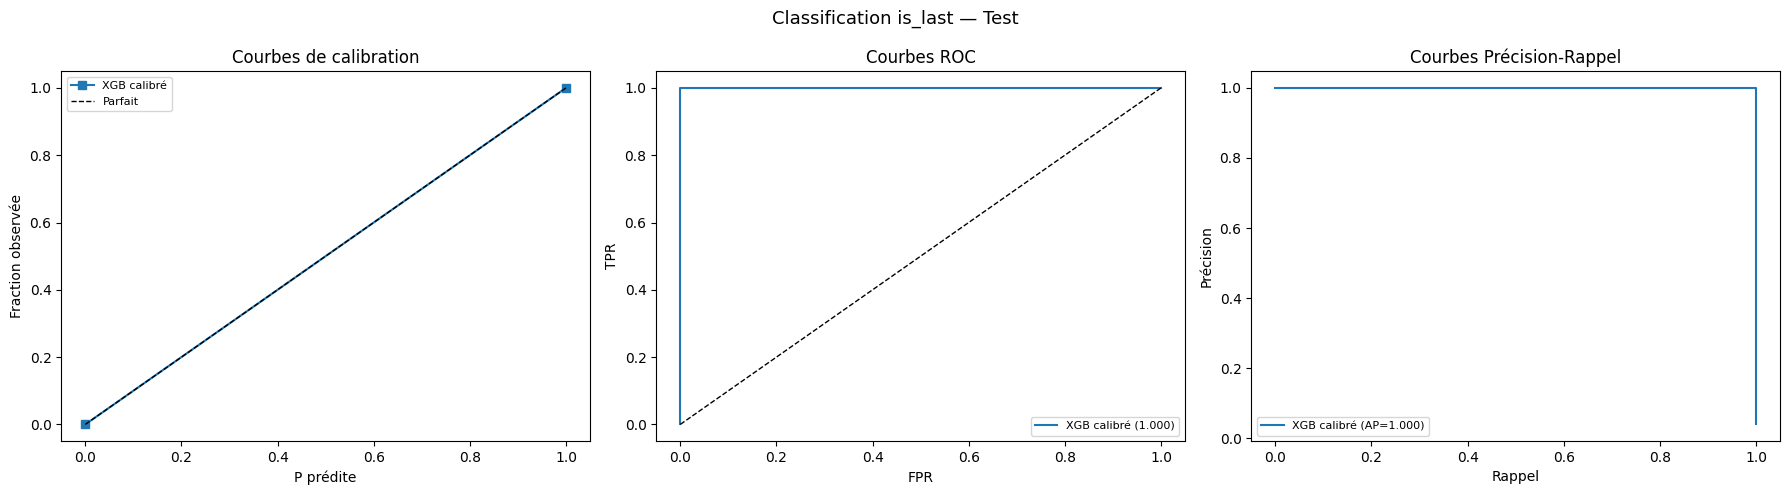

In [20]:
# ── Courbes ROC, calibration, PR (utils.py) ───────────────────────────────────
plot_calibration_roc(
    y_true_last,
    {"XGB calibré": y_proba_last},
    title="Classification is_last — Test"
)


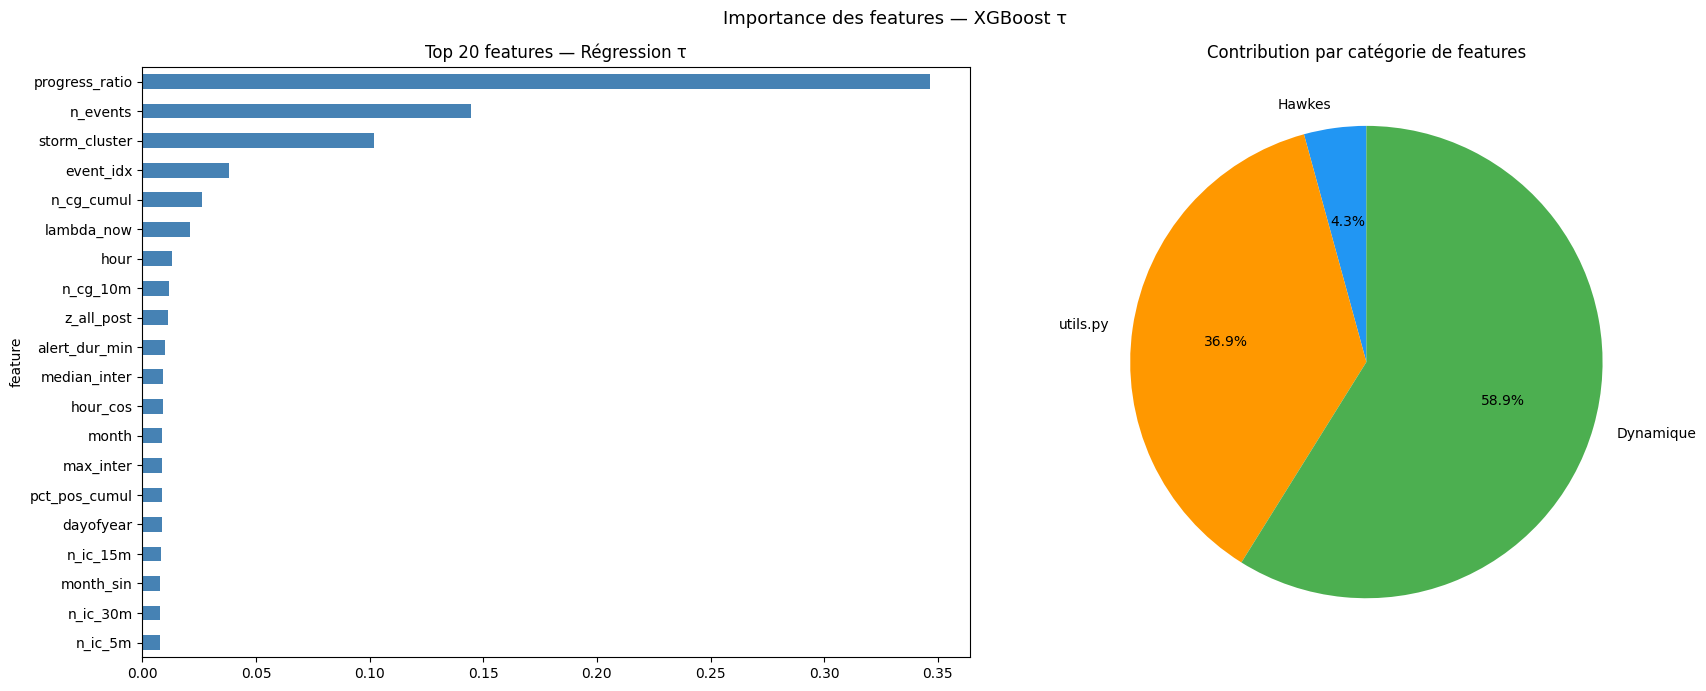

,feature,importance
67,progress_ratio,0.346569
66,n_events,0.144498
50,storm_cluster,0.101942
65,event_idx,0.038209
13,n_cg_cumul,0.026140
64,lambda_now,0.020889
52,hour,0.013064
23,n_cg_10m,0.011800
62,z_all_post,0.011473
14,alert_dur_min,0.009993


In [21]:
# ── Importance des features ───────────────────────────────────────────────────
if hasattr(model_reg, "feature_importances_"):
    feat_imp = pd.DataFrame({
        "feature":    ALL_FEATURES,
        "importance": model_reg.feature_importances_,
    }).sort_values("importance", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Top 20 — régression
    feat_imp.head(20).plot.barh(x="feature", y="importance", ax=axes[0],
                                 color="steelblue", legend=False)
    axes[0].set_title("Top 20 features — Régression τ")
    axes[0].invert_yaxis()

    # Catégories de features
    cats = {
        "Hawkes":    [f for f in ALL_FEATURES if f in FEATURES_HAWKES],
        "utils.py":  [f for f in ALL_FEATURES if f in FEATURES_UTILS],
        "Dynamique": [f for f in ALL_FEATURES if f in FEATURES_DYN],
    }
    cat_imp = {cat: feat_imp[feat_imp["feature"].isin(feats)]["importance"].sum()
               for cat, feats in cats.items()}
    axes[1].pie(cat_imp.values(), labels=cat_imp.keys(),
                autopct="%1.1f%%", startangle=90,
                colors=["#2196F3", "#FF9800", "#4CAF50"])
    axes[1].set_title("Contribution par catégorie de features")

    plt.suptitle("Importance des features — XGBoost τ", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
    plt.show()
    display(feat_imp.head(30))


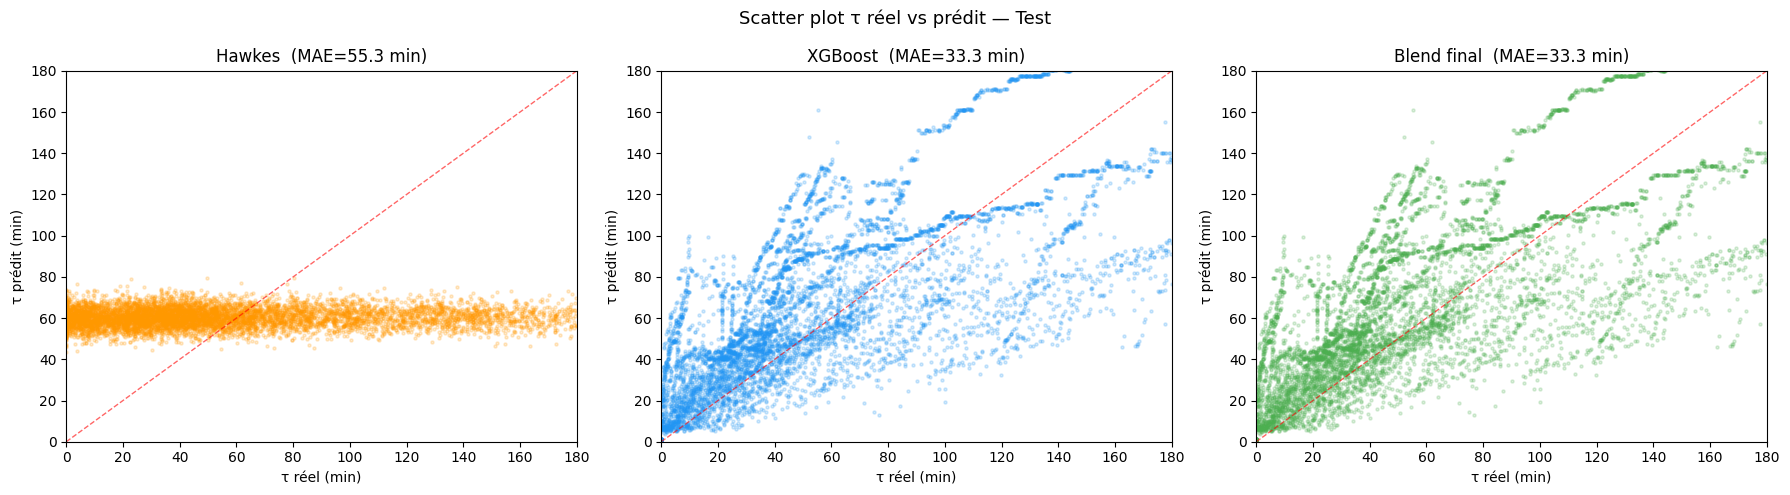

In [22]:
# ── Scatter τ réel vs prédit ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

test_df = df_cg[test_mask].copy()
sample  = test_df.sample(min(8000, len(test_df)), random_state=RANDOM_STATE)

for ax, col, name, color in [
    (axes[0], "tau_pred_tau_mean", "Hawkes",    "#FF9800"),
    (axes[1], "tau_pred_xgb",      "XGBoost",   "#2196F3"),
    (axes[2], "tau_pred_final",    "Blend final","#4CAF50"),
]:
    ax.scatter(sample["tau_true_min"], sample[col],
               s=5, alpha=0.2, color=color)
    mx = min(180, max(sample["tau_true_min"].max(), sample[col].max()))
    ax.plot([0,mx],[0,mx], "r--", alpha=0.6, lw=1)
    mae = mean_absolute_error(test_df["tau_true_min"], test_df[col])
    ax.set_title(f"{name}  (MAE={mae:.1f} min)")
    ax.set_xlabel("τ réel (min)")
    ax.set_ylabel("τ prédit (min)")
    ax.set_xlim(0,mx); ax.set_ylim(0,mx)

plt.suptitle("Scatter plot τ réel vs prédit — Test", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "scatter_tau.png"), dpi=150, bbox_inches="tight")
plt.show()


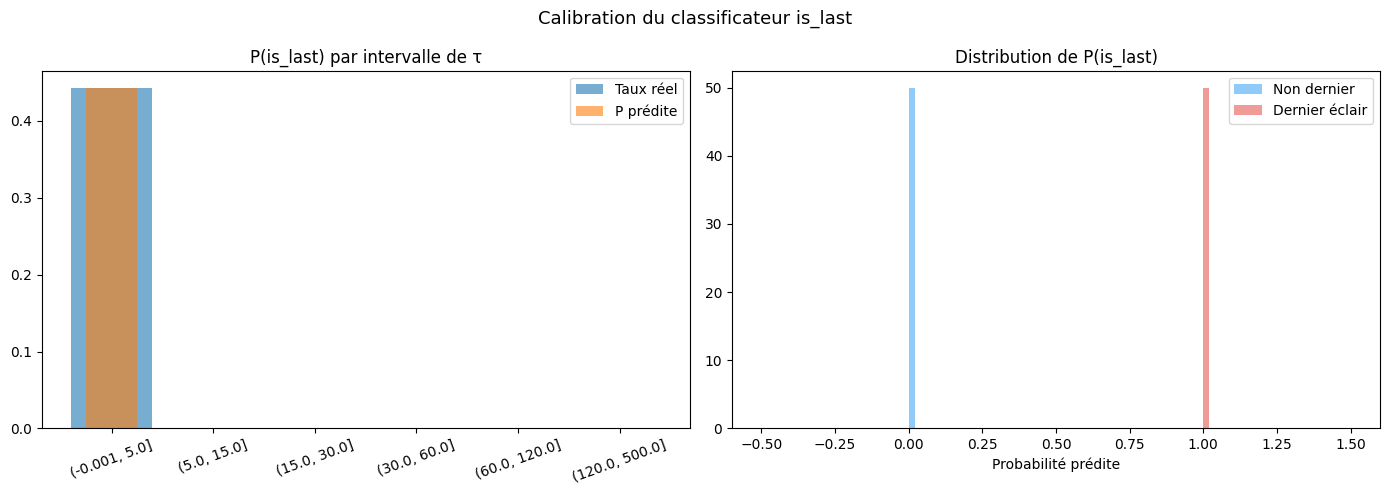

In [23]:
# ── Calibration P(is_last) par bin de τ réel ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test_df["tau_bin"] = pd.cut(test_df["tau_true_min"],
                             bins=[0,5,15,30,60,120,500], include_lowest=True)

# Probabilité moyenne prédite vs taux réel
cal = test_df.groupby("tau_bin", observed=True).agg(
    proba_mean=("proba_is_last","mean"),
    taux_reel=("is_last","mean"),
    n=("is_last","count")
).reset_index()

axes[0].bar(range(len(cal)), cal["taux_reel"],  alpha=0.6, label="Taux réel")
axes[0].bar(range(len(cal)), cal["proba_mean"], alpha=0.6, label="P prédite", width=0.5)
axes[0].set_xticks(range(len(cal)))
axes[0].set_xticklabels([str(b) for b in cal["tau_bin"]], rotation=20)
axes[0].set_title("P(is_last) par intervalle de τ")
axes[0].legend()

# Distribution des probas pour is_last=0 vs is_last=1
axes[1].hist(test_df.loc[test_df["is_last"]==0, "proba_is_last"],
             bins=50, alpha=0.5, density=True, label="Non dernier", color="#2196F3")
axes[1].hist(test_df.loc[test_df["is_last"]==1, "proba_is_last"],
             bins=50, alpha=0.5, density=True, label="Dernier éclair", color="#E53935")
axes[1].set_title("Distribution de P(is_last)")
axes[1].set_xlabel("Probabilité prédite")
axes[1].legend()

plt.suptitle("Calibration du classificateur is_last", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_is_last.png"), dpi=150, bbox_inches="tight")
plt.show()


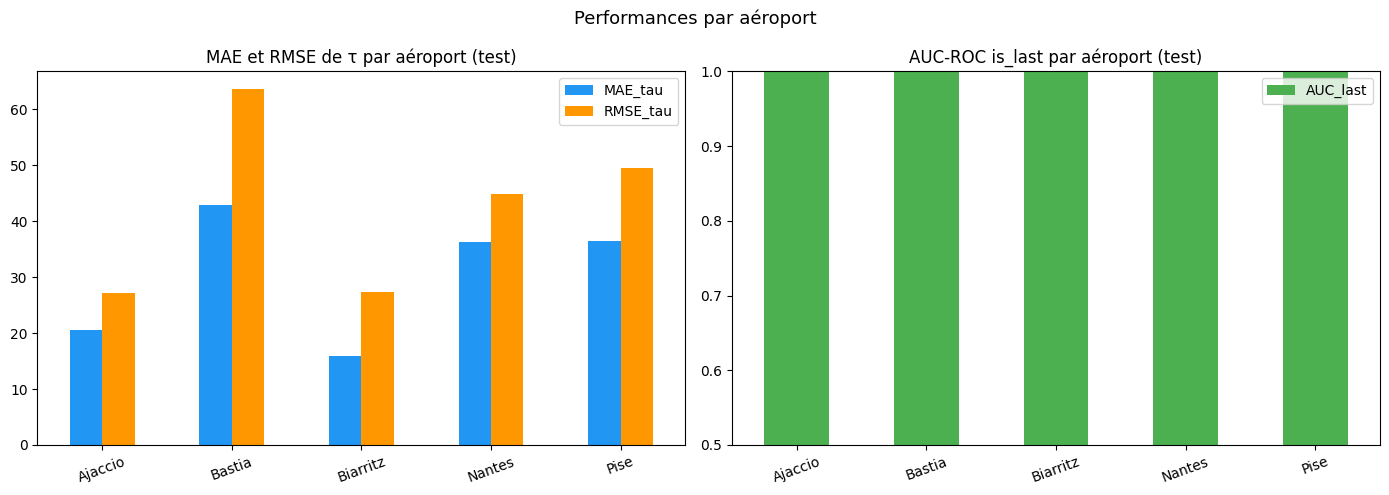

In [24]:
# ── MAE par aéroport ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_airport.set_index("airport")[["MAE_tau","RMSE_tau"]].plot.bar(
    ax=axes[0], color=["#2196F3","#FF9800"])
axes[0].set_title("MAE et RMSE de τ par aéroport (test)")
axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=20)

df_airport.set_index("airport")[["AUC_last"]].plot.bar(
    ax=axes[1], color="#4CAF50")
axes[1].set_title("AUC-ROC is_last par aéroport (test)")
axes[1].set_ylim(0.5, 1.0)
axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Performances par aéroport", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "perf_aeroport.png"), dpi=150, bbox_inches="tight")
plt.show()


## 14. Sauvegarde des modèles et résultats

In [25]:
print("=" * 60)
print("SAUVEGARDE")
print("=" * 60)

# ── Modèles ──────────────────────────────────────────────────────────────────
hawkes_params = {
    "mu": mu_opt, "alpha": alpha_opt, "beta": beta_opt, "delta": delta_opt,
    "gamma": GAMMA, "n_sim": N_SIM,
    "max_time_min": MAX_TIME_MIN, "intensity_threshold": INTENSITY_THRESHOLD,
}

for fname, obj in [
    ("hawkes_params.pkl",   hawkes_params),
    ("model_regression.pkl", model_reg),
    ("model_classifier.pkl", model_clf),
    ("blend_config.pkl",    {"hawkes_weight": best_w, "xgb_weight": 1-best_w}),
    ("feature_list.pkl",    ALL_FEATURES),
]:
    path = os.path.join(OUTPUT_DIR, fname)
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  ✅ {fname}")

# ── Prédictions complètes ─────────────────────────────────────────────────────
cols_save = (
    ["airport", "airport_alert_id", "date", "split",
     "tau_true_min", "is_last",
     "tau_pred_tau_mean", "tau_pred_tau_median",
     "tau_pred_tau_q05", "tau_pred_tau_q95",
     "tau_pred_xgb", "tau_pred_final",
     "proba_is_last",
     "z_all_post", "z_ic_post", "lambda_now"]
)
df_cg[cols_save].to_csv(
    os.path.join(OUTPUT_DIR, "predictions_completes.csv"), index=False)
print("  ✅ predictions_completes.csv")

# ── Métriques ─────────────────────────────────────────────────────────────────
metrics_all = {
    "regression_test":    df_reg_metrics.to_dict(),
    "classification_test": metrics_clf,
    "hawkes_params":       hawkes_params,
    "blend_weights":       {"hawkes": best_w, "xgb": 1-best_w},
    "n_features":          len(ALL_FEATURES),
    "split": {
        "train_years": f"≤{TRAIN_YEAR_MAX}",
        "val_year":    VAL_YEAR,
        "test_years":  f"≥{VAL_YEAR+1}",
    }
}
import json as _json
with open(os.path.join(OUTPUT_DIR, "metrics_summary.json"), "w") as f:
    _json.dump(metrics_all, f, indent=2, default=str)
print("  ✅ metrics_summary.json")

# ── Stats par aéroport ────────────────────────────────────────────────────────
df_airport.to_csv(os.path.join(OUTPUT_DIR, "perf_par_aeroport.csv"), index=False)
print("  ✅ perf_par_aeroport.csv")

# ── Importance features ───────────────────────────────────────────────────────
if hasattr(model_reg, "feature_importances_"):
    feat_imp.to_csv(os.path.join(OUTPUT_DIR, "feature_importance.csv"), index=False)
    print("  ✅ feature_importance.csv")

print(f"\n{'='*60}")
print("RÉCAPITULATIF FINAL")
print(f"{'='*60}")
print(f"\nHAWKES   MAE={df_reg_metrics.loc['Hawkes','MAE']:.2f} min  "
      f"Corr={df_reg_metrics.loc['Hawkes','Corr']:.3f}")
print(f"XGBOOST  MAE={df_reg_metrics.loc['XGBoost','MAE']:.2f} min  "
      f"Corr={df_reg_metrics.loc['XGBoost','Corr']:.3f}")
print(f"BLEND    MAE={df_reg_metrics.loc['Blend final','MAE']:.2f} min  "
      f"Corr={df_reg_metrics.loc['Blend final','Corr']:.3f}")
print(f"\nCLASSIF  AUC={metrics_clf['AUC-ROC ↑']:.4f}  "
      f"Brier={metrics_clf['Brier ↓']:.4f}  "
      f"AP={metrics_clf['AP ↑']:.4f}")
print(f"\nFichiers sauvegardés dans : {OUTPUT_DIR}/")


SAUVEGARDE
  ✅ hawkes_params.pkl
  ✅ model_regression.pkl
  ✅ model_classifier.pkl
  ✅ blend_config.pkl
  ✅ feature_list.pkl
  ✅ predictions_completes.csv
  ✅ metrics_summary.json
  ✅ perf_par_aeroport.csv
  ✅ feature_importance.csv

RÉCAPITULATIF FINAL

HAWKES   MAE=55.30 min  Corr=0.034
XGBOOST  MAE=33.32 min  Corr=0.826
BLEND    MAE=33.32 min  Corr=0.826

CLASSIF  AUC=1.0000  Brier=0.0000  AP=1.0000

Fichiers sauvegardés dans : hawkes_utils_outputs/
